In [1]:
import pandas as pd

rfm_df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\rfm_features.csv"
)

In [2]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [3]:
rfm_df.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [5]:
rfm_features = rfm_df[
    ["Recency", "Frequency", "Monetary"]
]

In [6]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

In [9]:
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

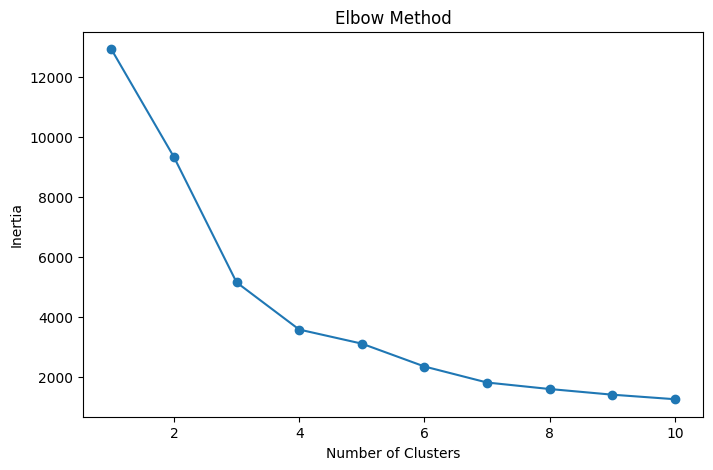

In [10]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm_df["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [12]:
rfm_df["Cluster"].value_counts()

Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64

In [13]:
cluster_summary = rfm_df.groupby(
    "Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


In [15]:
import plotly.express as px

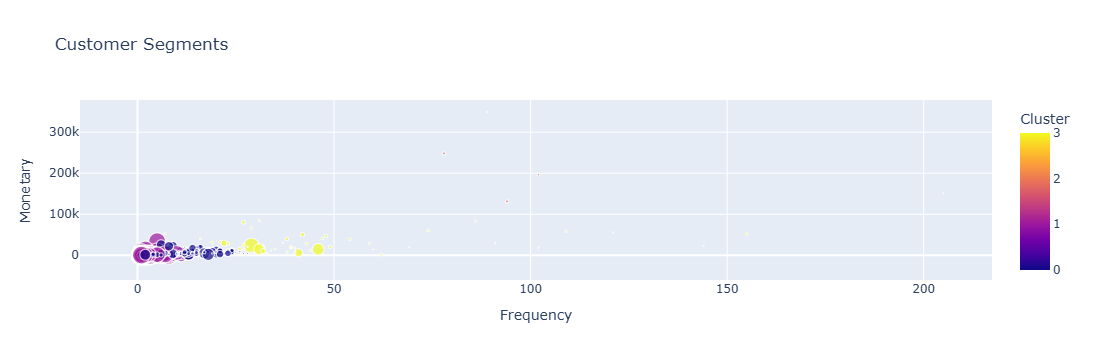

In [20]:
fig = px.scatter(
    rfm_df,
    x="Frequency",
    y="Monetary",
    color="Cluster",
    size="Recency",
    hover_data=["CustomerID"],
    title="Customer Segments"
)

fig.show()

In [21]:
rfm_df.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\customer_segments.csv",
    index=False
)

In [22]:
segment_map = {

    0: "Regular Customers",

    1: "At Risk Customers",

    2: "Ultra VIP Customers",

    3: "Loyal High-Value Customers"
}

In [23]:
rfm_df["Segment"] = rfm_df[
    "Cluster"
].map(segment_map)

In [24]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,165,11,372.86,1,At Risk Customers
1,12347,3,2,1323.32,0,Regular Customers
2,12348,74,1,222.16,0,Regular Customers
3,12349,43,3,2671.14,0,Regular Customers
4,12351,11,1,300.93,0,Regular Customers


In [25]:
rfm_df.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\customer_segments_labeled.csv",
    index=False
)